# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Asphalt 90°</font>

<font size="6">Test 1: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.9226499901912737
Average Fz in the averaging interval [None:None]: -1.532217940201996
Maximum Fz in the plotting interval [None:None]: 0.18450113932291667 at timestep 1444
Time step where Fx drops below 1: 0


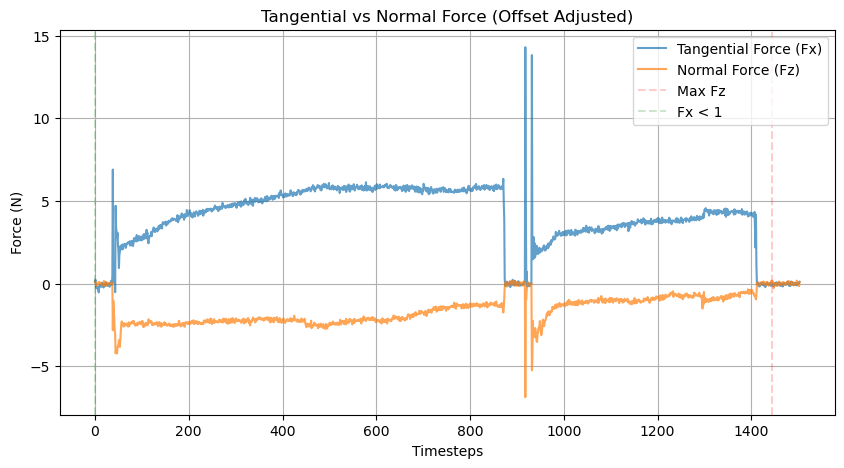

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231753.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 2: (partially worked / failed)</font>

Length from cut_1 to avg_end: 368
Average Fx in the averaging interval [1150:1518]: 3.956939388703609
Average Fz in the averaging interval [1150:1518]: -0.11694833506708557
Maximum Fz in the plotting interval [1150:None]: 0.42169189453125 at timestep 1348
Time step where Fx drops below 1: 1518


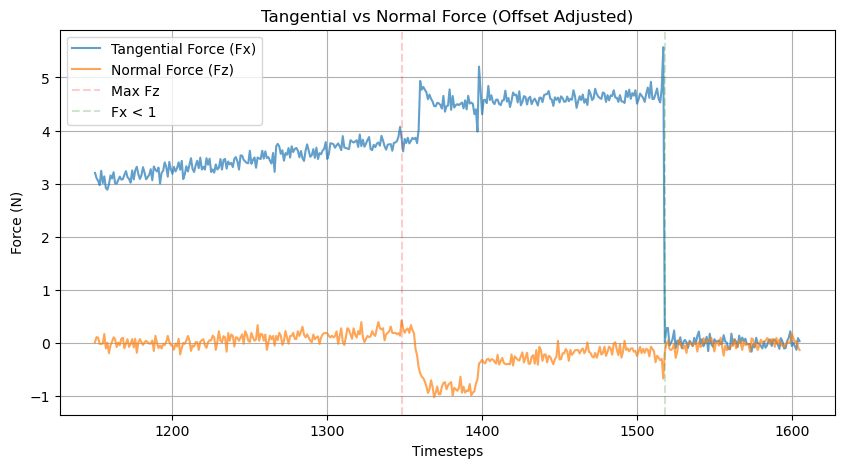

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231755.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=1150, cut_2=None, avg_end=1518, offset_position='end', offset_length=15)

<font size="6">Test 3: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.4425425238528495
Average Fz in the averaging interval [None:None]: -1.4001681570279396
Maximum Fz in the plotting interval [None:None]: 0.18161621093750002 at timestep 23
Time step where Fx drops below 1: 0


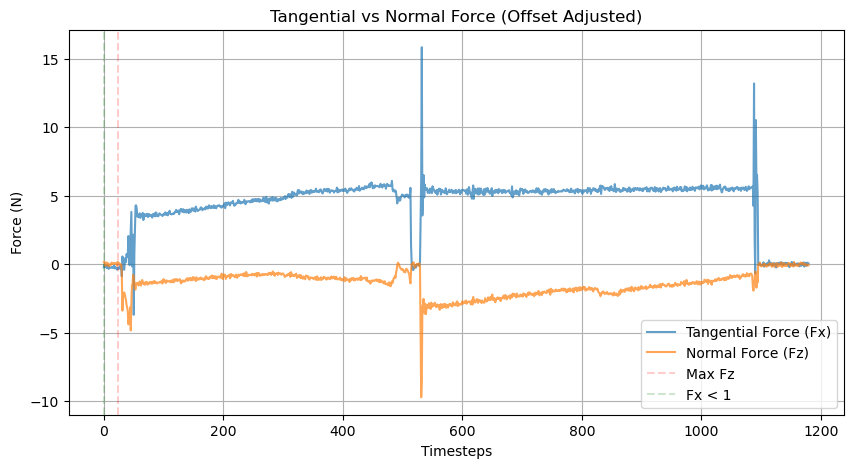

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231757.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 4: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.648674659903273
Average Fz in the averaging interval [None:None]: -0.8773723484512839
Maximum Fz in the plotting interval [None:None]: 0.16614583333333333 at timestep 18
Time step where Fx drops below 1: 0


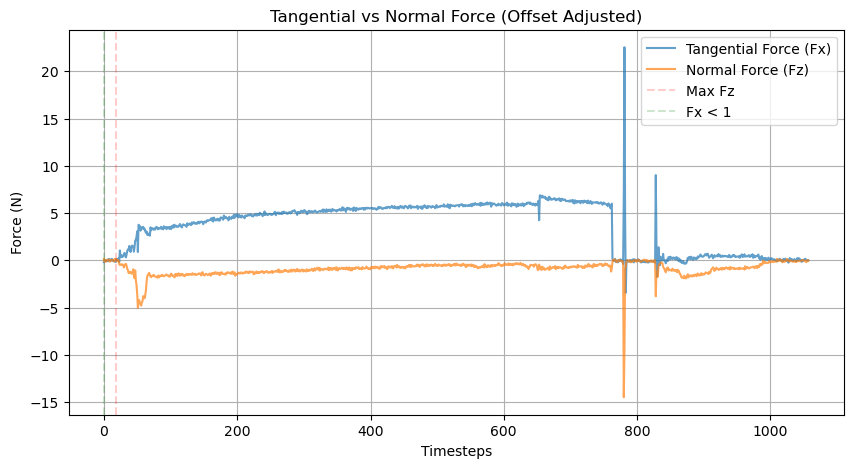

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231758.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 5: (failed)</font>

Average Fx in the averaging interval [None:None]: 2.3937156242933058
Average Fz in the averaging interval [None:None]: -0.8597419705506217
Maximum Fz in the plotting interval [None:None]: 0.1925984700520833 at timestep 819
Time step where Fx drops below 1: 0


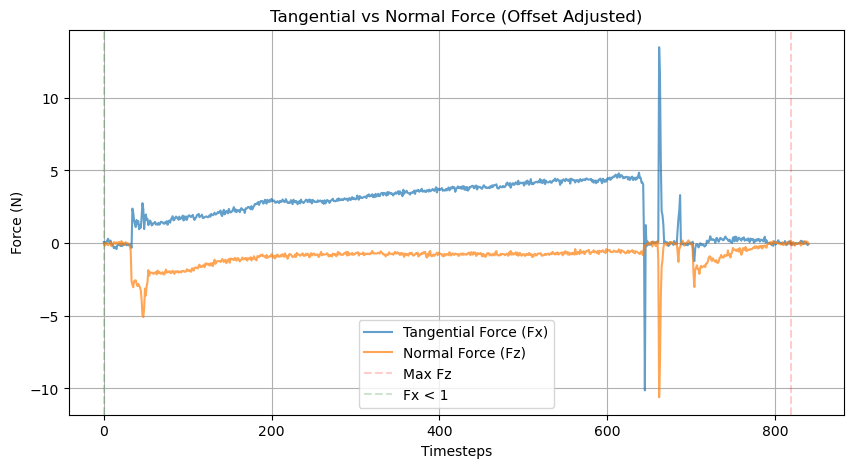

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231800.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 6: (failed)</font>

Average Fx in the averaging interval [None:None]: 2.177648587691347
Average Fz in the averaging interval [None:None]: -0.9312411638111595
Maximum Fz in the plotting interval [None:None]: 0.21759440104166672 at timestep 465
Time step where Fx drops below 1: 0


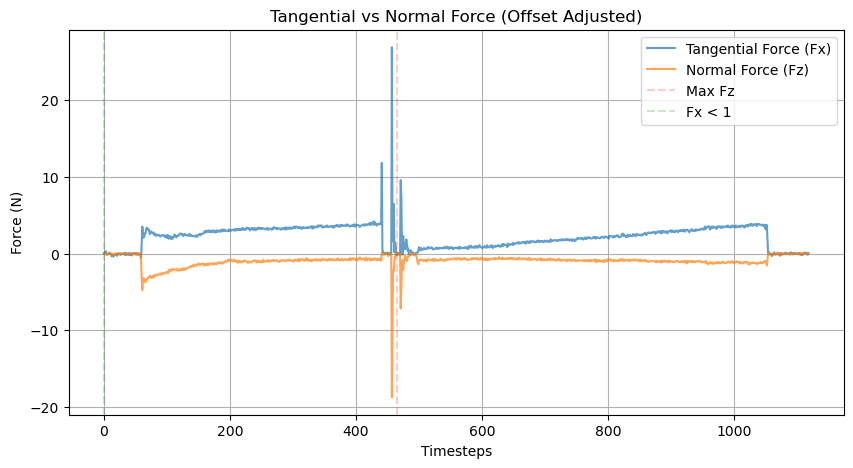

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231801.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 7: (failed)</font>

Average Fx in the averaging interval [None:None]: 4.940723318963835
Average Fz in the averaging interval [None:None]: -2.0590324088318708
Maximum Fz in the plotting interval [None:None]: 0.20734863281250004 at timestep 247
Time step where Fx drops below 1: 0


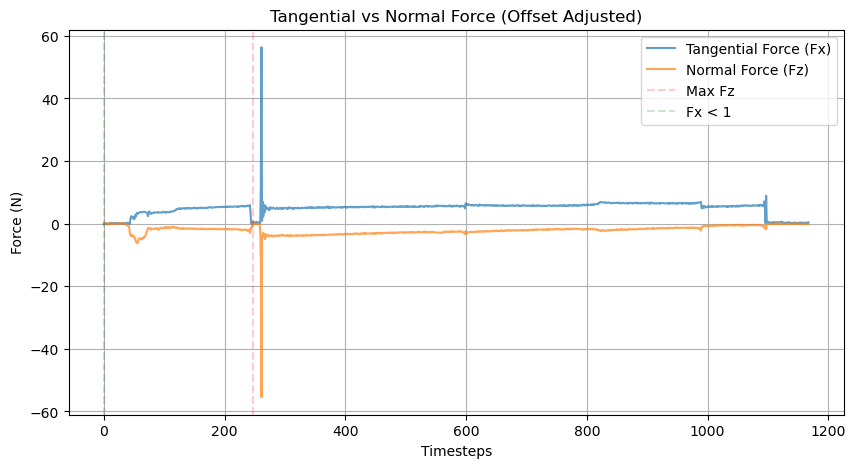

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231802.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 8: (failed)</font>

Average Fx in the averaging interval [None:None]: 2.7127742821499843
Average Fz in the averaging interval [None:None]: -1.440955271800803
Maximum Fz in the plotting interval [None:None]: 0.21604003906250002 at timestep 882
Time step where Fx drops below 1: 0


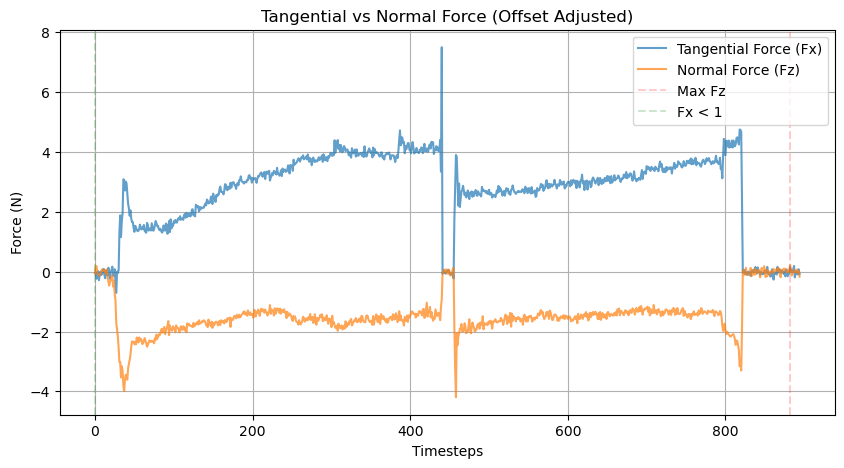

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231804.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 9: (failed)</font>

Average Fx in the averaging interval [None:None]: 3.546570960980919
Average Fz in the averaging interval [None:None]: -1.900512275087243
Maximum Fz in the plotting interval [None:None]: 0.2066975911458333 at timestep 616
Time step where Fx drops below 1: 0


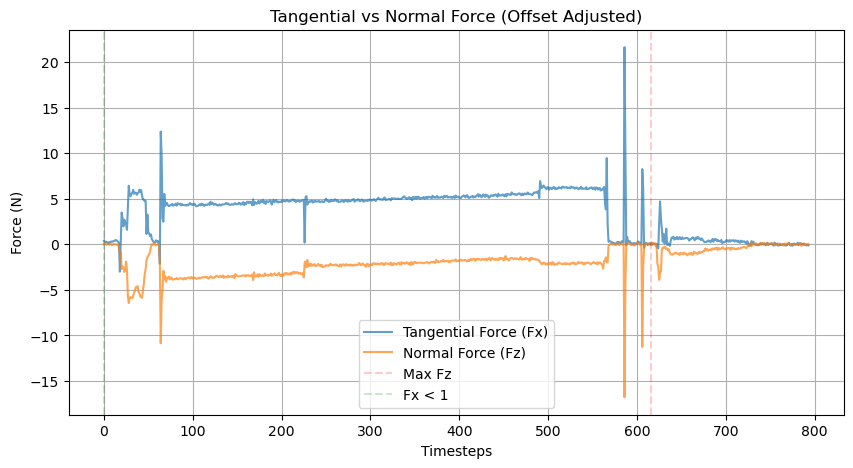

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231805.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=None, cut_2=None, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 227
Average Fx in the averaging interval [1000:1227]: 5.913820619485102
Average Fz in the averaging interval [1000:1227]: 0.11515227778542592
Maximum Fz in the plotting interval [1000:None]: 0.6742146809895834 at timestep 1190
Time step where Fx drops below 1: 1227


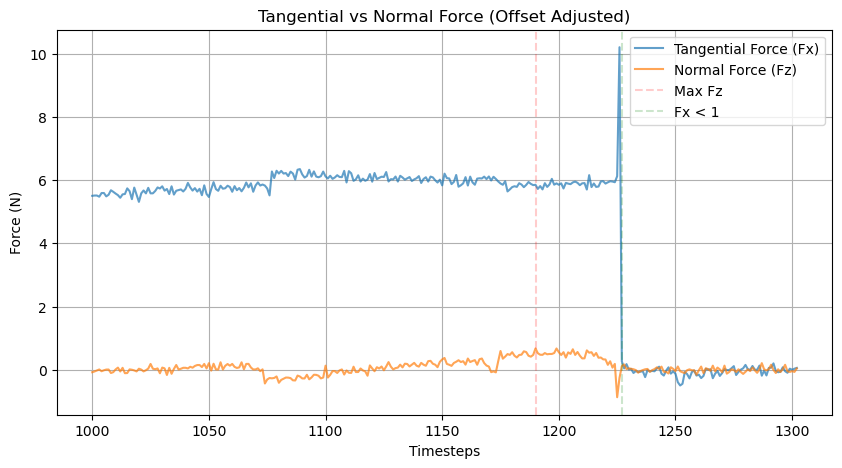

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_90_5N//log_202405231806.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=1000, cut_2=None, avg_end=1227, offset_position='end', offset_length=15)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//90//Asphalt_90_stats.csv", index=False)

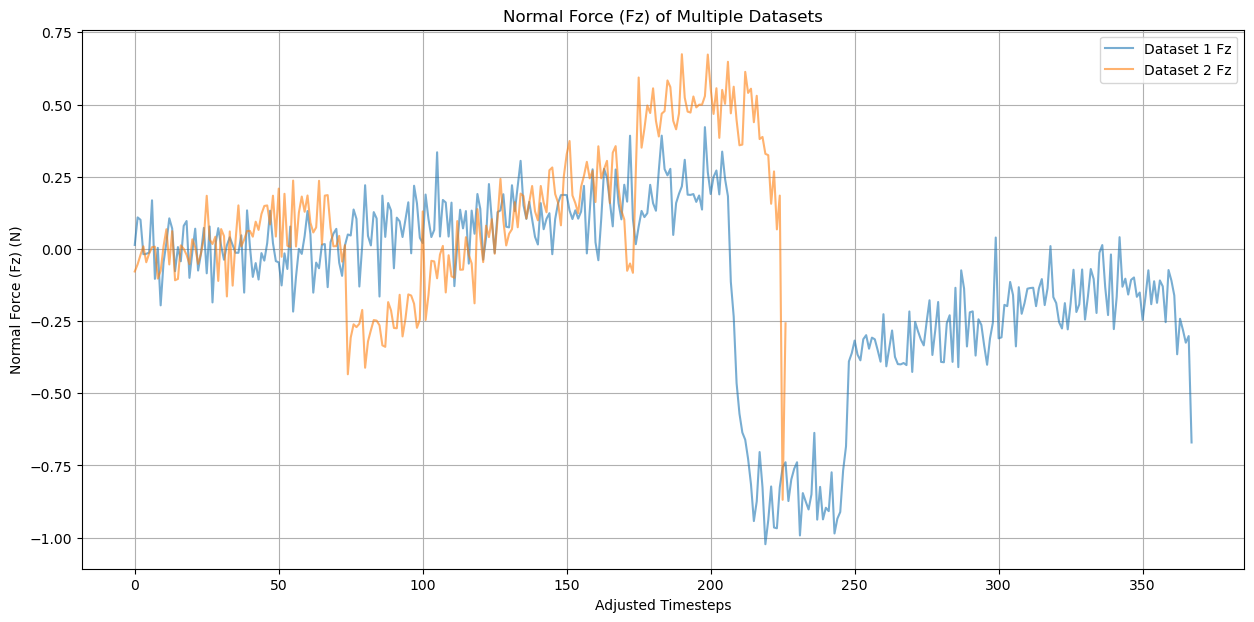

Average of maximum Fz forces: 0.5479532877604167
Standard deviation of maximum Fz forces: 0.12626139322916669
Average of average Fz forces: -0.0008980286408298496
Standard deviation of average Fz forces: 0.11605030642625574
Average of average Fx forces: 4.935380004094355
Standard deviation of average Fx forces: 0.9784406153907468


In [18]:
tests = [test_2, test_10]
ends = [end_2, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//90//Asphalt_90"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)